# Covariance inspection (config 2)

Loads an aggregates H5 produced by `compute_aggregates.py` and forms
the per-GMD-bin covariance matrices used for ghost imaging:

  * **Photon–photon**:  `Cov(A) = <AtA> - <A><A>ᵀ`    shape `(n_pixels, n_pixels)`
  * **Photon–electron**: `Cov(A, D) = <AtD> - <A><D>ᵀ`  shape `(n_pixels, n_tof)`

One panel per GMD bin. Diverging colormap is centred at zero so the
sign of off-diagonal elements is readable; the limits are the 99th
percentile of `|cov|` per bin so a single hot pixel can't wash out
the structure.

In [1]:
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt

import config
from compute_aggregates import load_aggregates

%matplotlib inline

## Parameters

In [2]:
AGGREGATES_FILE = config.COMBINED_DIR / "test_config2_aggregates.h5"

# Percentile used to set symmetric colour limits (per panel). Lower
# values exaggerate weaker structure; higher values flatten outliers.
CLIM_PERCENTILE = 99.0

## Load

In [3]:
agg = load_aggregates(AGGREGATES_FILE)

print(f"file              : {AGGREGATES_FILE}")
print(f"input H5          : {agg.metadata.get('input_h5')}")
print(f"VLS crop          : {agg.metadata.get('vls_crop_roi')}")
print(f"background        : {agg.metadata.get('background_type')} "
      f"{agg.metadata.get('background_roi', '')}")
print(f"n_pixels          : {agg.n_pixels}")
print(f"n_tof             : {agg.n_tof}  ({agg.tof_edges[0]:.1f} .. {agg.tof_edges[-1]:.1f} ns)")
print(f"n_gmd_bins        : {agg.n_gmd_bins}")
print(f"shots per bin     : {agg.n_per_bin}")
print(f"total shots used  : {int(agg.n_per_bin.sum())}")

file              : C:\Users\oga17\OneDrive - Imperial College London\Python\glycine2026\11022188\processed\combined\test_config2_aggregates.h5
input H5          : 11022188\processed\combined\test_config2.h5
VLS crop          : [380, 500]
background        : auto [0, 5]
n_pixels          : 120
n_tof             : 125  (500.0 .. 1750.0 ns)
n_gmd_bins        : 7
shots per bin     : [ 70372  61414  95121 114629  73175  19667   1793]
total shots used  : 436171


## Compute covariances

Per-bin subtract the rank-1 mean term from each second-moment
aggregate. Empty bins (`n_per_bin == 0`) are NaN by construction so
the subtraction propagates NaN cleanly.

In [4]:
# Cov(A) per bin: (n_gmd, n_pixels, n_pixels)
cov_AA = agg.AtA - agg.A[:, :, None] * agg.A[:, None, :]
# Cov(A, D) per bin: (n_gmd, n_pixels, n_tof)
cov_AD = agg.AtD - agg.A[:, :, None] * agg.D[:, None, :]

# Quick sanity numbers.
for b in range(agg.n_gmd_bins):
    if agg.n_per_bin[b] == 0:
        continue
    eig_min = float(np.linalg.eigvalsh(cov_AA[b]).min())
    rng = f"[{agg.gmd_edges[b]:.3f}, {agg.gmd_edges[b+1]:.3f})"
    print(f"bin {b}  GMD {rng:<18}  n={int(agg.n_per_bin[b]):>7d}  "
          f"Cov(A) eig_min={eig_min:.3e}  "
          f"|Cov(A,D)|_F={np.linalg.norm(cov_AD[b]):.3e}")

bin 0  GMD [0.000, 0.050)      n=  70372  Cov(A) eig_min=2.939e+02  |Cov(A,D)|_F=1.006e+02
bin 1  GMD [0.050, 0.100)      n=  61414  Cov(A) eig_min=2.913e+02  |Cov(A,D)|_F=1.172e+02
bin 2  GMD [0.100, 0.200)      n=  95121  Cov(A) eig_min=2.923e+02  |Cov(A,D)|_F=1.233e+02
bin 3  GMD [0.200, 0.400)      n= 114629  Cov(A) eig_min=2.931e+02  |Cov(A,D)|_F=1.275e+02
bin 4  GMD [0.400, 0.800)      n=  73175  Cov(A) eig_min=2.883e+02  |Cov(A,D)|_F=1.242e+02
bin 5  GMD [0.800, 1.500)      n=  19667  Cov(A) eig_min=2.868e+02  |Cov(A,D)|_F=1.239e+02
bin 6  GMD [1.500, 3.000)      n=   1793  Cov(A) eig_min=2.311e+02  |Cov(A,D)|_F=2.401e+02


## Photon–photon covariance  `Cov(A) = <AtA> − <A><A>ᵀ`

Each panel is `Cov(A)` for one GMD bin. The bright diagonal is the
per-pixel variance; off-diagonal bands indicate correlated
fluctuations between VLS pixels (peak-shape jitter, mode hopping).

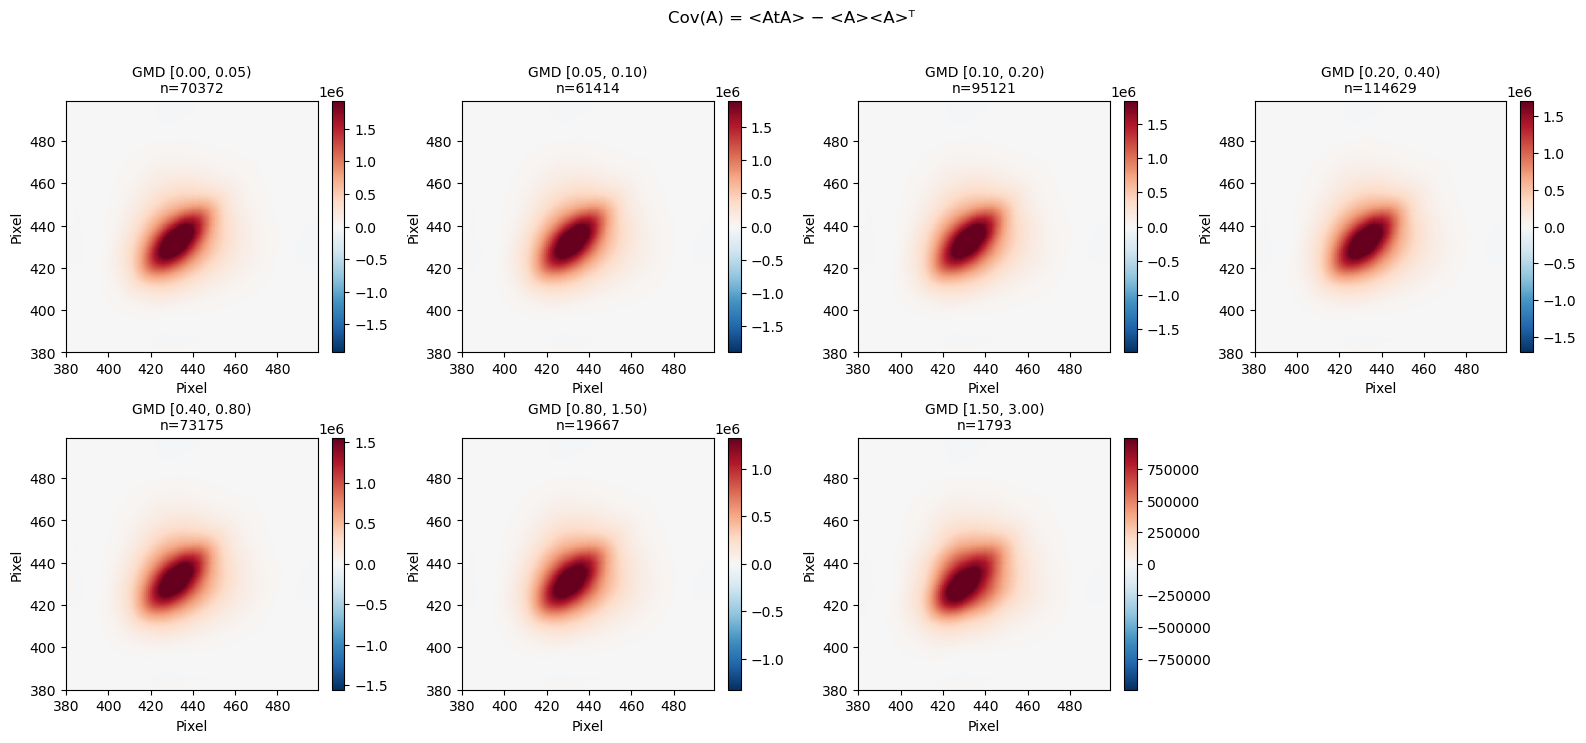

In [5]:
def _grid(n):
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    return rows, cols

rows, cols = _grid(agg.n_gmd_bins)
fig, axes = plt.subplots(rows, cols, figsize=(4.0 * cols, 3.6 * rows))
axes_flat = np.atleast_1d(axes).ravel()

extent = [agg.vls_pixels[0], agg.vls_pixels[-1],
          agg.vls_pixels[0], agg.vls_pixels[-1]]

for b in range(agg.n_gmd_bins):
    ax = axes_flat[b]
    M = cov_AA[b]
    if not np.isfinite(M).any():
        ax.set_title(f"bin {b}  (empty)")
        ax.axis("off")
        continue
    vmax = float(np.nanpercentile(np.abs(M), CLIM_PERCENTILE))
    im = ax.imshow(M, origin="lower", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, extent=extent, aspect="equal")
    ax.set_title(f"GMD [{agg.gmd_edges[b]:.2f}, {agg.gmd_edges[b+1]:.2f})\n"
                 f"n={int(agg.n_per_bin[b])}", fontsize=10)
    ax.set_xlabel("Pixel")
    ax.set_ylabel("Pixel")
    fig.colorbar(im, ax=ax, fraction=0.046)

for ax in axes_flat[agg.n_gmd_bins:]:
    ax.axis("off")

fig.suptitle("Cov(A) = <AtA> \u2212 <A><A>\u1d40", y=1.02)
fig.tight_layout()
plt.show()

## Photon–electron covariance  `Cov(A, D) = <AtD> − <A><D>ᵀ`

Each panel is the cross-covariance between VLS pixels (y-axis) and
eTOF bins (x-axis) for one GMD bin. Diagonal-like structure here is
the photon–electron correlation that drives ADMM spectral-domain
ghost imaging.

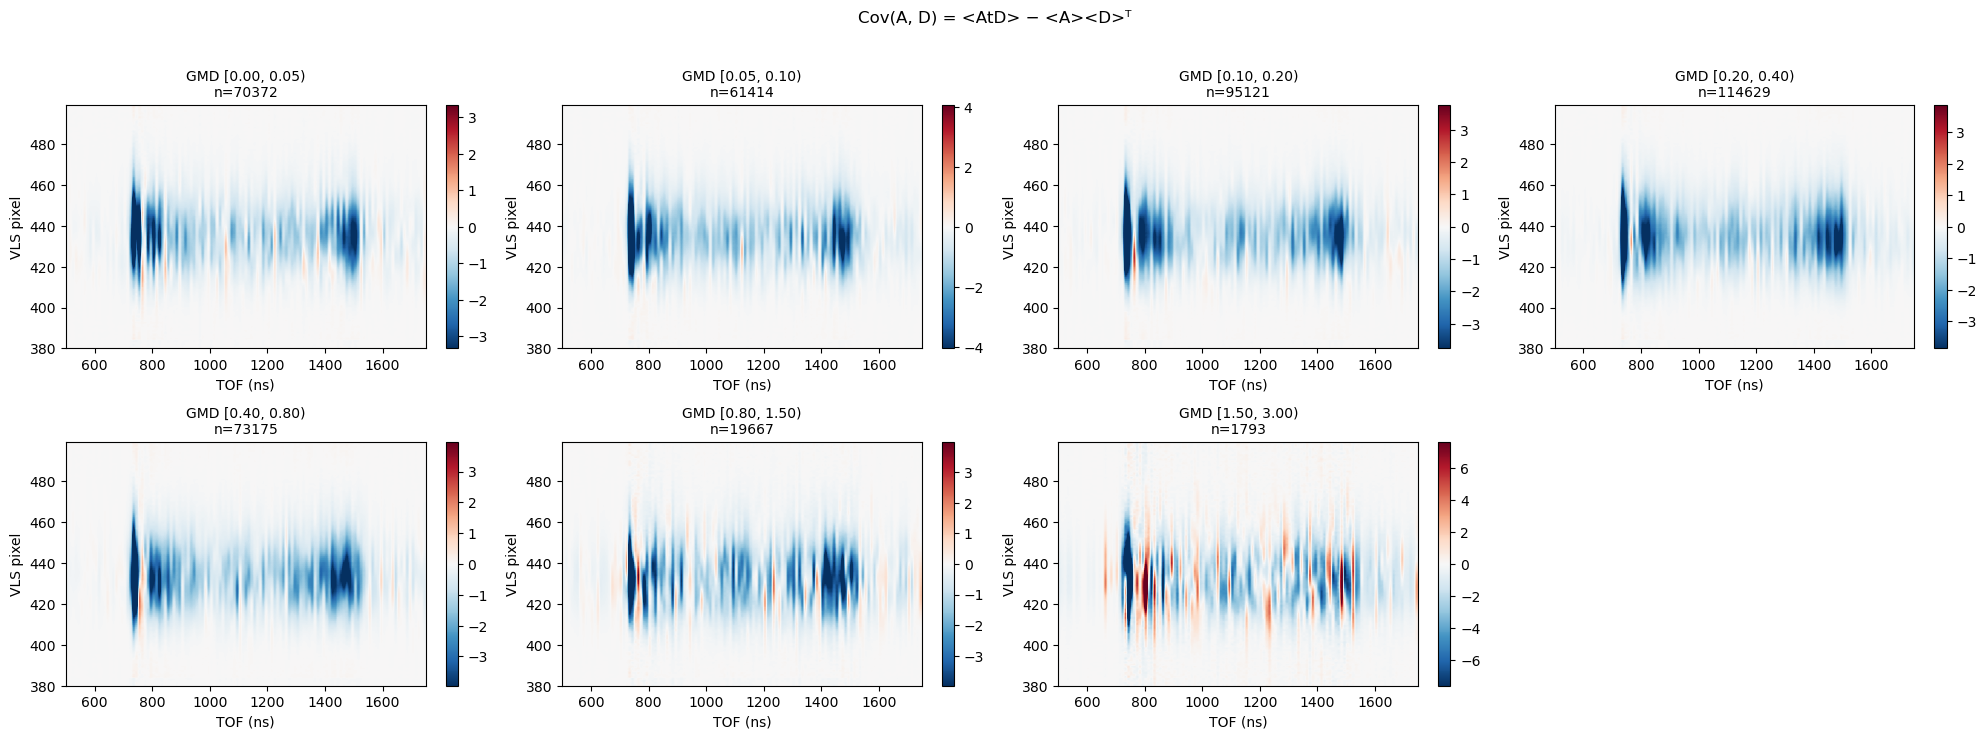

In [6]:
rows, cols = _grid(agg.n_gmd_bins)
fig, axes = plt.subplots(rows, cols, figsize=(5.0 * cols, 3.6 * rows))
axes_flat = np.atleast_1d(axes).ravel()

extent = [agg.tof_edges[0], agg.tof_edges[-1],
          agg.vls_pixels[0], agg.vls_pixels[-1]]

for b in range(agg.n_gmd_bins):
    ax = axes_flat[b]
    M = cov_AD[b]
    if not np.isfinite(M).any():
        ax.set_title(f"bin {b}  (empty)")
        ax.axis("off")
        continue
    vmax = float(np.nanpercentile(np.abs(M), CLIM_PERCENTILE))
    im = ax.imshow(M, origin="lower", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, extent=extent, aspect="auto")
    ax.set_title(f"GMD [{agg.gmd_edges[b]:.2f}, {agg.gmd_edges[b+1]:.2f})\n"
                 f"n={int(agg.n_per_bin[b])}", fontsize=10)
    ax.set_xlabel("TOF (ns)")
    ax.set_ylabel("VLS pixel")
    fig.colorbar(im, ax=ax, fraction=0.046)

for ax in axes_flat[agg.n_gmd_bins:]:
    ax.axis("off")

fig.suptitle("Cov(A, D) = <AtD> \u2212 <A><D>\u1d40", y=1.02)
fig.tight_layout()
plt.show()